# Linear Discriminant Analysis
Linear discriminant analysis was developed to model gaussian physical measurements when conditioned on a class (particularly Iris flowers) as a generative classification technique.

As discussed in the [classification readme](../../../README.md), generative methods try to estimate the bayes optimal classifier by factoring the posterior into the likelihood and prior.

$$
P(Y = y_c | X = x) = \frac{P(X = x | Y = y_c) \cdot P(Y = y_c)}{P(X=x)}
$$

Then we estimate likelihood and prior and multiply them to get an equivalent (since the marginal distribution of the data is the same for each class) quantity to the posterior, then after we have our posterior equivalents, picking the maximum of this quantity:

$$
\hat{f}(x) = \text{argmax}_{\text{y}_c} {\frac{P(X = x | Y = y_c) \cdot P(Y = y_c)}{P(X=x)}} \\
= \text{argmax}_{\text{y}_c} {P(X = x | Y = y_c) \cdot P(Y = y_c)}
$$

In the original context of LDA, the measurements of flowers were observed to be normally distributed based on their class so modeling the likelihood was straightforward.

It's straightforward to estimate the prior aspect, just getting the proportion of the class in the training data $(P(Y=y_c))$.

For the conditional likelihood by default (and because the ubiquity of guassian random variables) we assume the data is a multivariate gaussian in discrimnant analysis:

$$
X | {Y = y_c} \sim N(\mu_{y_c}, \Sigma_{y_c})
$$

With the following density function:

$$
pdf(X=x | Y = y_c) = \frac{1}{(2 \cdot \pi)^{\frac{2}{p}} \cdot |\Sigma_{y_c}|^{1/2}}e^{-\frac{1}{2}(x - \mu_c)^T\Sigma^{-1}(x - \mu_c)}
$$

In the same wa we ignored the marginal distribution of X for the posterior to get an equivalent quantity, we can do the same with the terms multiplied outside of expontential to get a equivalent expression to minimize (since they're constant across classes), also if we use the rank preserving transformation of log on the exponential we get the following equivalent expression to maximize across classes:

$$
log(pdf(X=x | Y = y_c)) \sim -\frac{1}{2}(x - \mu_c)^T\Sigma^{-1}_{y_c}(x - \mu_c) - log(|\Sigma_{y_c}|^{1/2})
$$

The linear part of linear discriminant analysis by assuming $\Sigma_{y_c} = \Sigma$:

$$
log(pdf(X=x | Y = y_c)) \sim -\frac{1}{2}(x - \mu_c)^T\Sigma^{-1}_{y_c}(x - \mu_c)
$$

And the decision boundary (equal probability of to most likely classes) becomes linear:

$$
log(pdf(X=x | Y = y_1)) = log(pdf(X=x | Y = y_2)) \\
-\frac{1}{2}(x - \mu_1)^T\Sigma^{-1}(x - \mu_1) = -\frac{1}{2}(x - \mu_2)^T\Sigma^{-1}(x - \mu_2) \\
-\frac{1}{2}(x^T\Sigma^{-1}x - 2 x^T \Sigma^{-1}\mu_1 + \mu_1^T\Sigma^{-1}\mu_1) = -\frac{1}{2}(x^T\Sigma^{-1}x - 2 x^T \Sigma^{-1}\mu_2 + \mu_1^T\Sigma^{-1}\mu_2) \\ 
\mu_1^T\Sigma^{-1}\mu_1 - 2 x^T \Sigma^{-1}\mu_1 = \mu_2^T\Sigma^{-1}\mu_2 - 2 x^T \Sigma^{-1}\mu_2
$$

If we don't assume a common covariance the problem becomes Quadratic Discriminant Analysis (QDA) and the boundary is quadratic, a subject of study outside of this notebook but we do look at it in the non-linear classification section of this repository.

Let's start with a generated example that matches the assumptions here.

### Generated Problem

In [1]:
import numpy as np
random_matrix = np.random.uniform(-.5, .5, (3,3))

common_covariance_matrix = random_matrix @ random_matrix.T
labeled_0_data = np.random.multivariate_normal([-1, -1.5, 2], common_covariance_matrix, (1000))
labeled_1_data = np.random.multivariate_normal([.5, -1.5, 1], common_covariance_matrix, (1000))

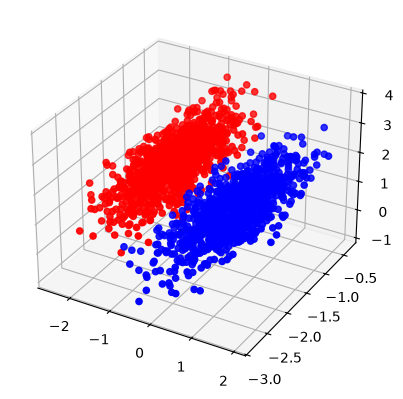

In [2]:
import matplotlib.pyplot as plt

ax = plt.figure().add_subplot(projection="3d")
ax.scatter3D(xs=labeled_0_data[:, 0], ys=labeled_0_data[:, 1], zs=labeled_0_data[:, 2], c="red")
ax.scatter3D(xs=labeled_1_data[:, 0], ys=labeled_1_data[:, 1], zs=labeled_1_data[:, 2], c="blue")
plt.show()

So above is the ground truth, now let's mix up the points.

In [31]:
dataset = np.concat([np.concat([labeled_0_data, np.zeros(shape=(labeled_0_data.shape[0], 1))], axis=1), np.concat([labeled_1_data, np.ones(shape=(labeled_1_data.shape[0], 1))], axis=1)], axis=0)
training_dataset = dataset[:1600, :]
test_dataset = dataset[:1600, :]

In [32]:
cov_label_1 = np.cov(training_dataset[training_dataset[:, -1] == 1][:, :-1], bias=False, rowvar=False)
cov_label_0 = np.cov(training_dataset[training_dataset[:, -1] == 0][:, :-1], bias=False, rowvar=False)
cov = ((training_dataset[training_dataset[:, -1] == 1].shape[0] - 1) * cov_label_1 + (training_dataset[training_dataset[:, -1] == 0].shape[0] - 1) * cov_label_0) / (training_dataset.shape[0] - 2)

In [33]:
cov, common_covariance_matrix

(array([[0.2330649 , 0.11011882, 0.13214084],
        [0.11011882, 0.14087477, 0.20532366],
        [0.13214084, 0.20532366, 0.33536473]]),
 array([[0.23130136, 0.11388812, 0.13618528],
        [0.11388812, 0.14457361, 0.21153877],
        [0.13618528, 0.21153877, 0.34653365]]))

Not bad on estimating our covariance matrix from our data, now for our means.

In [40]:
mean_label_1 = training_dataset[training_dataset[:, -1] == 1][:, :-1].mean(axis=0)
mean_label_0 = training_dataset[training_dataset[:, -1] == 0][:, :-1].mean(axis=0)


In [43]:
mean_label_0, [-1, -1.5, 2]

(array([-0.99768246, -1.48954676,  2.0138999 ]), [-1, -1.5, 2])

In [45]:
mean_label_1, [.5, -1.5, 1]

(array([ 0.4978559 , -1.50010556,  0.9886832 ]), [0.5, -1.5, 1])

Means are estimated nicely too.
With that training is done, now lets write our inference function and test it against our test dataset.

In [64]:
def predict_class(points, label_1_mean, label_0_mean, cov):
    inv_cov = np.linalg.inv(cov)
    offset_0 = label_0_mean.T @ inv_cov @ label_0_mean
    offset_1 = label_1_mean.T @ inv_cov @ label_1_mean

    linear_0 = 2 * points @ inv_cov @ label_0_mean
    linear_1= 2 * points @ inv_cov @ label_1_mean

    score_0 = offset_0 - linear_0
    score_1 = offset_1 - linear_1
    return (score_0 > score_1).astype(float)

result = predict_class(test_dataset[:, :-1], mean_label_1, mean_label_0, cov)

(result == test_dataset[:, -1]).mean()

np.float64(0.9975)

## todo:
1. randomize then split
2. include priors (both in math derivation and in your code)
3. Generate visualization of plane
3. discret features?
4. Two goals, assumptiosn, tests
5. Small scale real (int, inf)
6. large scale (inf)
